In [1]:
# Import used packages
import geopandas as gpd  # used to read the shapfile
import rasterio as rio   # used to read the raster (.tif) files
from rasterio.plot import show # used to make plots using rasterio
import matplotlib.pyplot as plt #to make plots using matplotlib

In [9]:
# Read your point shapefiles (Flooded and Non Flooded locations)
points=gpd.read_file(r'..\data\Sample_points\Points.shp')

In [11]:
# make columns to extract the values of each predictive feature
# for each point. 
points['DEM']=0 #
points['Slope']=0
points['Aspect']=0
points['Curvature']=0
points['TWI']=0
points['DTDrainage']=0
points['DTRoad']=0
points['DTRiver']=0
points['CN']=0
points['AP']=0  #Max daily precipitation
points['FP']=0  #Frequency of extreme precipitation event.

In [15]:
#The predictive features are in raster format so we use rasterio package to 
#read them and convert them to numpy array

DEM_raster=rio.open(r'..\data\Predictive_Features_resolution_30_m\DEM.tif')
DEM_arr=DEM_raster.read(1)

Slope_raster=rio.open(r'..\data\Predictive_Features_resolution_30_m\Slope.tif')
Slope_arr=Slope_raster.read(1)

Aspect_raster=rio.open(r'..\data\Predictive_Features_resolution_30_m\Aspect.tif')
Aspect_arr=Aspect_raster.read(1)

Curvature_raster=rio.open(r'..\data\Predictive_Features_resolution_30_m\Curvature.tif')
Curvature_arr=Curvature_raster.read(1)

TWI_raster=rio.open(r'..\data\Predictive_Features_resolution_30_m\TWI.tif')
TWI_arr=TWI_raster.read(1)

DTRoad_raster=rio.open(r'..\data\Predictive_Features_resolution_30_m\DTRoad.tif')
DTRoad_arr=DTRoad_raster.read(1)

DTRiver_raster=rio.open(r'..\data\Predictive_Features_resolution_30_m\DTRiver.tif')
DTRiver_arr=DTRiver_raster.read(1)

DTDrainage_raster=rio.open(r'..\data\Predictive_Features_resolution_30_m\DTDrainage.tif')
DTDrainage_arr=DTDrainage_raster.read(1)

CN_raster=rio.open(r'..\data\Predictive_Features_resolution_30_m\CN.tif')
CN_arr=CN_raster.read(1)

AP_raster=rio.open(r'..\data\Predictive_Features_resolution_30_m\AP.tif')
AP_arr=AP_raster.read(1)

FP_raster=rio.open(r'..\data\Predictive_Features_resolution_30_m\FP.tif')
FP_arr=FP_raster.read(1)

<Axes: >

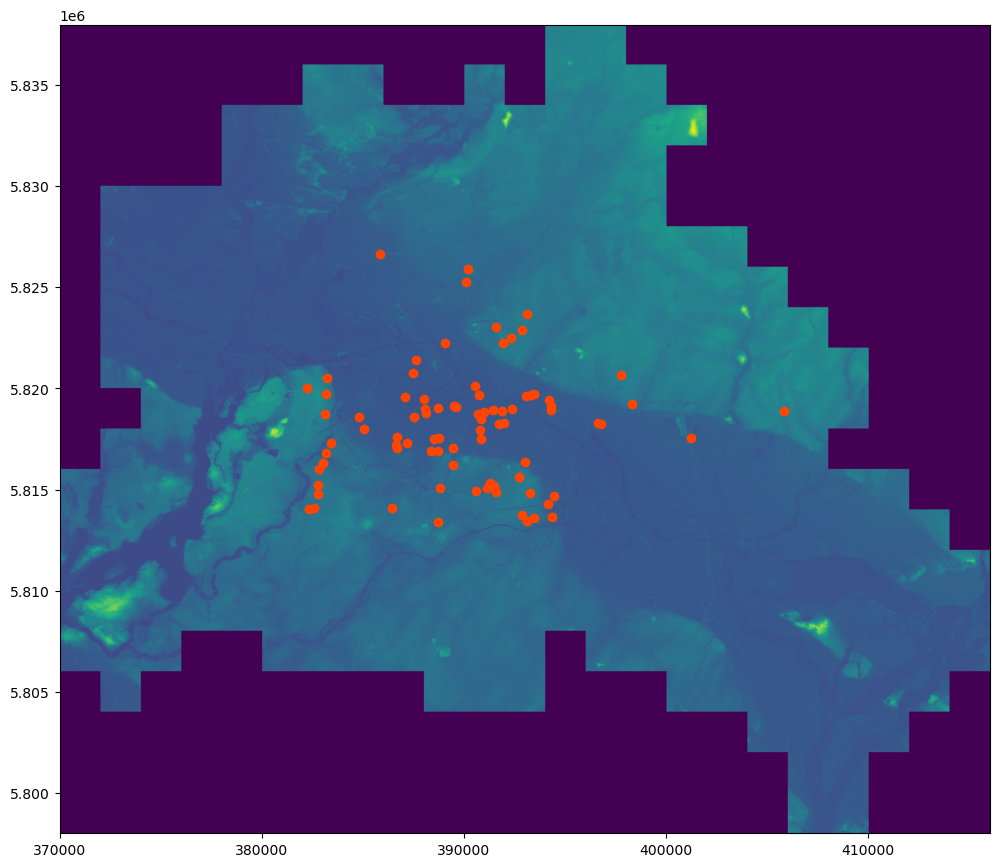

In [16]:
#show point and raster on a matplotlib plot
fig, ax = plt.subplots(figsize=(12,12))
points.plot(ax=ax, color='orangered')
show(DEM_raster, ax=ax)

In [22]:
import numpy as np
# 如果还没提前创建字段，可以先创建
feature_names = [
    'DEM', 'Slope', 'Aspect', 'Curvature', 'DTRoad',
    'DTRiver', 'DTDrainage', 'TWI', 'CN', 'AP', 'FP'
]

# 强制初始化为 float 类型
for name in feature_names:
    points[name] = np.nan
points[feature_names] = points[feature_names].astype(float)


# Extracting the raster values to the points shapefile
for index, row in points.iterrows():
    longitude = row.geometry.x
    latitude = row.geometry.y

    rowIndex, colIndex = DEM_raster.index(longitude, latitude)

    points.loc[index, 'DEM'] = DEM_arr[rowIndex, colIndex]
    points.loc[index, 'Slope'] = Slope_arr[rowIndex, colIndex]
    points.loc[index, 'Aspect'] = Aspect_arr[rowIndex, colIndex]
    points.loc[index, 'Curvature'] = Curvature_arr[rowIndex, colIndex]
    points.loc[index, 'DTRoad'] = DTRoad_arr[rowIndex, colIndex]
    points.loc[index, 'DTRiver'] = DTRiver_arr[rowIndex, colIndex]
    points.loc[index, 'DTDrainage'] = DTDrainage_arr[rowIndex, colIndex]
    points.loc[index, 'TWI'] = TWI_arr[rowIndex, colIndex]
    points.loc[index, 'CN'] = CN_arr[rowIndex, colIndex]
    points.loc[index, 'AP'] = AP_arr[rowIndex, colIndex]
    points.loc[index, 'FP'] = FP_arr[rowIndex, colIndex]

points.head()

,Label,geometry,DEM,Slope,Aspect,Curvature,TWI,DTDrainage,DTRoad,DTRiver,CN,AP,FP
0,0,POINT Z (382328.441 5814043.781 0),44.160000,3.916919,107.641121,0.090000,7.286532,58.309521,28.284271,680.000000,58.0,80.427414,4.540030
1,0,POINT Z (382580.854 5814097.359 0),39.450001,0.182592,101.309929,-0.099998,8.051311,20.000000,10.000000,901.387817,100.0,84.038452,4.807138
2,0,POINT Z (382758.655 5814802.211 0),49.650002,1.502409,151.847183,0.600006,5.943513,50.990196,28.284271,875.556946,72.0,75.800056,3.624787
3,0,POINT Z (382782.361 5815220.465 0),50.520000,1.499948,343.641327,-0.629993,6.638300,60.827625,42.426407,806.039673,58.0,86.827484,4.670529
4,0,POINT Z (382814.111 5816035.383 0),46.340000,1.873798,96.581848,0.279999,5.722488,50.000000,10.000000,820.792297,72.0,97.448822,5.402912


In [23]:
points.head() # to have a look on the calculated fields.

,Label,geometry,DEM,Slope,Aspect,Curvature,TWI,DTDrainage,DTRoad,DTRiver,CN,AP,FP
0,0,POINT Z (382328.441 5814043.781 0),44.160000,3.916919,107.641121,0.090000,7.286532,58.309521,28.284271,680.000000,58.0,80.427414,4.540030
1,0,POINT Z (382580.854 5814097.359 0),39.450001,0.182592,101.309929,-0.099998,8.051311,20.000000,10.000000,901.387817,100.0,84.038452,4.807138
2,0,POINT Z (382758.655 5814802.211 0),49.650002,1.502409,151.847183,0.600006,5.943513,50.990196,28.284271,875.556946,72.0,75.800056,3.624787
3,0,POINT Z (382782.361 5815220.465 0),50.520000,1.499948,343.641327,-0.629993,6.638300,60.827625,42.426407,806.039673,58.0,86.827484,4.670529
4,0,POINT Z (382814.111 5816035.383 0),46.340000,1.873798,96.581848,0.279999,5.722488,50.000000,10.000000,820.792297,72.0,97.448822,5.402912


In [24]:
# Save the points file
points.to_file('points_data.shp') # save as a shapfile 

d:\miniconda\envs\dem_work\Lib\site-packages\pyogrio\geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [25]:
# or
points.to_pickle('points_data.pkl') # save as a pickle.